# Self Matching Task 行为可视化与设计空间探索 V2

这个 notebook 是对 `Visualization/app_server.py + visualization_app.html` 的 Python/Jupyter 复现版。
它从真实 raw CSV 出发，逐步复现网页中的核心逻辑：

1. 读取 `EXP_data_group*.csv`，补出 `Condition`、`Identity`、`ResponseIsMatch` 等分析列。
2. 对每个被试探索 RT、ACC、遗漏率、Response/Matching 键偏向。
3. 复现网页中的 CRF/SPE 思路：按 RT 分位数计算 Self/Stranger 的匹配键比例曲线。
4. 在 P/T/W 设计空间中查看每个被试和每个设计组的 SPE 分布。
5. 输出可接入 Sigmoid 生成模型或 GP 建模优化的 feature table。

实验范式：Self Matching Task, Sui et al. (2012)。

运行方式：从上到下一格一格运行。想看单个被试时，只改“选择被试”那一格的 `GROUP_ID` 和 `SUBJECT_ID`。

## 可视化思路与建模用途

**被试层面**

- RT 分布：看 Self vs Stranger、Matching vs NonMatching 是否存在速度差异，以及是否有长尾/截尾。
- ACC 与遗漏率：判断被试是否真正完成任务，或是否被短 W 条件压制造成大量 omission。
- ResponseIsMatch / CRF：把反应映射成“匹配键”概率，接近 DDM 上边界命中概率；这是网页 CRF 的核心。
- Trial sequence：看学习、疲劳、策略切换或异常段落。

**行为实验层面**

- 条件交互：`Identity × Condition × Response` 下的 RT/ACC/omission。
- 每被试 SPE：同时看 `SPE_ACC = ACC_self - ACC_stranger` 与 `SPE_RT = RT_stranger_correct - RT_self_correct`。后者为正表示 Self 更快。
- CRF-SPE 曲线：看 SPE 是否只出现在快反应、慢反应，或跨整个 RT 动态过程都存在。

**设计空间层面**

- P/T/W 组合下的被试级 SPE 分布：不要只看组均值，要看组内离散度。
- 设计组质量：高 omission 的组可能不适合直接校准 DDM，也可能代表边界/时限机制。
- GP 优化：在 `(P, T, W, M=T+W)` 上学习行为层 SPE 或 HDDM 参数残差，输出候选设计点的不确定性。

**接 Sigmoid / GP**

- Sigmoid 生成模型：用 `T -> v`、`P -> practice effect`、`M=T+W -> boundary/time pressure` 的解释性先验。
- GP：当前 8 个设计点很少，更适合做“残差捕捉/不确定性地图”，而不是完全替代 Sigmoid。

In [4]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None
    plt.style.use("default")

try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Plotly available:", PLOTLY_AVAILABLE)
print("Seaborn available:", sns is not None)

Plotly available: False
Seaborn available: True


In [5]:
PROJECT_ROOT = Path(r"D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design")
RAW_DIR = PROJECT_ROOT / "2_Data" / "Real_Data" / "UnExtact" / "raw"
VIS_DIR = PROJECT_ROOT / "1_Code" / "Python_for_Check" / "Visualization"
V2_DIR = VIS_DIR / "V2"
OUT_DIR = V2_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR)
print("raw csv count:", len(list(RAW_DIR.glob("EXP_data_group*.csv"))))
print("OUT_DIR:", OUT_DIR)

RAW_DIR: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Real_Data\UnExtact\raw
raw csv count: 88
OUT_DIR: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\Visualization\V2\outputs


## 复现实验规则与网页后端逻辑

下面这组函数来自 `app_server.py` 的核心逻辑：

- `get_match_key(subject_id)`：该被试哪个键代表“匹配”。
- `get_correct_order(subject_id)`：shape-label 的正确匹配关系。
- `compute_condition(shape, label, subject_id)`：当前 trial 是 Matching 还是 NonMatching。
- `ResponseIsMatch`：被试是否按了“匹配键”，用于 CRF/DDM 上边界近似。

注意：`T/W` 在 raw CSV 中以秒为单位；图表和设计空间常用毫秒显示。

In [6]:
CONDITIONS = {
    1: {"P": 0, "T": 0.03, "W": 0.3, "label": "G1 | P0_T30_W300"},
    2: {"P": 0, "T": 0.03, "W": 0.6, "label": "G2 | P0_T30_W600"},
    3: {"P": 120, "T": 0.03, "W": 0.6, "label": "G3 | P120_T30_W600"},
    4: {"P": 120, "T": 0.08, "W": 0.6, "label": "G4 | P120_T80_W600"},
    5: {"P": 8, "T": 0.10, "W": 1.1, "label": "G5 | P8_T100_W1100"},
    6: {"P": 120, "T": 0.50, "W": 1.5, "label": "G6 | P120_T500_W1500"},
    7: {"P": 0, "T": 0.10, "W": 1.1, "label": "G7 | P0_T100_W1100"},
    8: {"P": 120, "T": 0.03, "W": 0.8, "label": "G8 | P120_T30_W800"},
    9: {"P": 120, "T": 0.08, "W": 0.8, "label": "G9 | P120_T80_W800"},
}
QUALITY_MAP = {1: "exclude", 2: "exclude", 3: "caution", 4: "good", 5: "good", 6: "good", 7: "good", 8: "good", 9: "good"}

def get_pairing_rules(subject_id: int):
    mod_result = subject_id % 4
    rules = {
        0: {"square": {"self": "f", "stranger": "j"}, "circle": {"self": "j", "stranger": "f"}},
        1: {"square": {"self": "j", "stranger": "f"}, "circle": {"self": "f", "stranger": "j"}},
        2: {"square": {"self": "j", "stranger": "f"}, "circle": {"self": "f", "stranger": "j"}},
        3: {"square": {"self": "f", "stranger": "j"}, "circle": {"self": "j", "stranger": "f"}},
    }
    return rules[mod_result]

def get_match_key(subject_id: int):
    return ["f", "j", "j", "f"][(subject_id - 1) % 4]

def get_correct_order(subject_id: int):
    if subject_id % 2 == 0:
        return {"square": "self", "circle": "stranger"}
    return {"square": "stranger", "circle": "self"}

def compute_condition(shape: str, label: str, subject_id: int):
    expected_label = get_correct_order(subject_id)[shape]
    return "Matching" if label == expected_label else "NonMatching"

def parse_file_ids(path: Path):
    gid, sid = path.stem.replace("EXP_data_group", "").split("_")[:2]
    return int(gid), int(sid)

In [7]:
def load_one_file(path: Path) -> pd.DataFrame:
    gid_from_file, sid_from_file = parse_file_ids(path)
    df = pd.read_csv(path)
    df["source_file"] = path.name

    df["groupID"] = df["groupID"].astype(int)
    df["subjectID"] = df["subjectID"].astype(int)
    df["trialID"] = df["trialID"].astype(int)
    df["Shape"] = df["Shape"].astype(str).str.strip().str.lower()
    df["Label"] = df["Label"].astype(str).str.strip().str.lower()
    df["Response"] = df["Response"].astype(str).str.strip().str.lower()
    df["CorrectKey"] = df["CorrectKey"].astype(str).str.strip().str.lower()
    df["stage"] = df["stage"].fillna("formal").astype(str)
    df["RT"] = pd.to_numeric(df["RT"], errors="coerce")
    df["Correct"] = pd.to_numeric(df["Correct"], errors="coerce")
    df["responded"] = df["RT"].notna() & (~df["Response"].isin(["na", "nan", ""]))

    df["Condition"] = [compute_condition(sh, lb, int(sid)) for sh, lb, sid in zip(df["Shape"], df["Label"], df["subjectID"])]
    df["Identity"] = np.where(df["Label"].eq("self"), "Self", "Stranger")
    df["MatchKey"] = [get_match_key(int(sid)) for sid in df["subjectID"]]
    df["ResponseIsMatch"] = np.where(df["responded"], df["Response"].eq(df["MatchKey"]), np.nan)

    df["P"] = pd.to_numeric(df["P"], errors="coerce")
    df["T"] = pd.to_numeric(df["T"], errors="coerce")
    df["W"] = pd.to_numeric(df["W"], errors="coerce")
    df["T_ms"] = df["T"] * 1000
    df["W_ms"] = df["W"] * 1000
    df["M_ms"] = df["T_ms"] + df["W_ms"]
    df["RT_ms"] = df["RT"] * 1000
    df["quality"] = df["groupID"].map(QUALITY_MAP)
    df["groupID_from_file"] = gid_from_file
    df["subjectID_from_file"] = sid_from_file
    return df

def load_all_raw(raw_dir=RAW_DIR) -> pd.DataFrame:
    files = sorted(raw_dir.glob("EXP_data_group*.csv"))
    if not files:
        raise FileNotFoundError(f"No EXP_data_group*.csv found in {raw_dir}")
    return pd.concat([load_one_file(f) for f in files], ignore_index=True)

all_df = load_all_raw()
print(all_df.shape)
display(all_df.head())

(52320, 29)


,groupID,subjectID,gender,age,handedness,stage,trialID,P,T,W,Shape,Label,CorrectKey,Response,RT,Correct,source_file,responded,Condition,Identity,MatchKey,ResponseIsMatch,T_ms,W_ms,M_ms,RT_ms,quality,groupID_from_file,subjectID_from_file
0,1,1,1,23,2,formal,1,0,0.03,0.3,square,self,j,nan,NaN,0,EXP_data_group1_1.csv,False,NonMatching,Self,f,NaN,30.0,300.0,330.0,NaN,exclude,1,1
1,1,1,1,23,2,formal,2,0,0.03,0.3,square,stranger,f,nan,NaN,0,EXP_data_group1_1.csv,False,Matching,Stranger,f,NaN,30.0,300.0,330.0,NaN,exclude,1,1
2,1,1,1,23,2,formal,3,0,0.03,0.3,circle,self,f,f,0.23854,1,EXP_data_group1_1.csv,True,Matching,Self,f,1.0,30.0,300.0,330.0,238.5398,exclude,1,1
3,1,1,1,23,2,formal,4,0,0.03,0.3,circle,stranger,j,nan,NaN,0,EXP_data_group1_1.csv,False,NonMatching,Stranger,f,NaN,30.0,300.0,330.0,NaN,exclude,1,1
4,1,1,1,23,2,formal,5,0,0.03,0.3,square,self,j,nan,NaN,0,EXP_data_group1_1.csv,False,NonMatching,Self,f,NaN,30.0,300.0,330.0,NaN,exclude,1,1


In [8]:
file_manifest = (
    all_df.groupby(["groupID", "subjectID", "source_file"], as_index=False)
    .agg(n_trials=("trialID", "size"), n_formal=("stage", lambda s: (s == "formal").sum()), P=("P", "first"), T_ms=("T_ms", "first"), W_ms=("W_ms", "first"))
    .sort_values(["groupID", "subjectID"])
)

group_counts = file_manifest.groupby("groupID").agg(
    n_subjects=("subjectID", "nunique"),
    files=("source_file", "count"),
    P=("P", "first"),
    T_ms=("T_ms", "first"),
    W_ms=("W_ms", "first"),
)
group_counts["M_ms"] = group_counts["T_ms"] + group_counts["W_ms"]
display(group_counts)
print("ID mismatch rows:", len(all_df[(all_df["groupID"] != all_df["groupID_from_file"]) | (all_df["subjectID"] != all_df["subjectID_from_file"])]))

,n_subjects,files,P,T_ms,W_ms,M_ms
groupID,,,,,,
1,11,11,0,30.0,300.0,330.0
2,12,12,0,30.0,600.0,630.0
3,10,10,120,30.0,600.0,630.0
4,11,11,120,80.0,600.0,680.0
5,11,11,8,100.0,1100.0,1200.0
6,10,10,120,500.0,1500.0,2000.0
7,12,12,120,30.0,800.0,830.0
8,11,11,120,80.0,800.0,880.0


ID mismatch rows: 0


## 选择一个被试：逐个探索实际反应

修改下面的 `GROUP_ID`、`SUBJECT_ID` 后，从这一格继续往下运行即可。

In [9]:
GROUP_ID = 4
SUBJECT_ID = int(file_manifest.loc[file_manifest["groupID"].eq(GROUP_ID), "subjectID"].iloc[0])

subj = all_df[(all_df["groupID"] == GROUP_ID) & (all_df["subjectID"] == SUBJECT_ID)].copy()
formal = subj[subj["stage"].eq("formal")].copy()
responded = formal[formal["responded"]].copy()
correct = responded[responded["Correct"].eq(1)].copy()

print(f"Selected: G{GROUP_ID}, S{SUBJECT_ID}, file={subj['source_file'].iloc[0]}")
print(f"formal={len(formal)}, responses={len(responded)}, omission={(1-len(responded)/max(len(formal),1))*100:.1f}%, accuracy={responded['Correct'].mean()*100:.1f}%")
print("Match key:", get_match_key(SUBJECT_ID), "Correct order:", get_correct_order(SUBJECT_ID))
display(subj.head(12))

Selected: G4, S1, file=EXP_data_group4_1.csv
formal=520, responses=358, omission=31.2%, accuracy=75.4%
Match key: f Correct order: {'square': 'stranger', 'circle': 'self'}


,groupID,subjectID,gender,age,handedness,stage,trialID,P,T,W,Shape,Label,CorrectKey,Response,RT,Correct,source_file,responded,Condition,Identity,MatchKey,ResponseIsMatch,T_ms,W_ms,M_ms,RT_ms,quality,groupID_from_file,subjectID_from_file
18360,4,1,1,23,2,practice,1,120,0.08,0.6,square,self,j,nan,NaN,0,EXP_data_group4_1.csv,False,NonMatching,Self,f,NaN,80.0,600.0,680.0,NaN,good,4,1
18361,4,1,1,23,2,practice,2,120,0.08,0.6,square,stranger,f,f,0.660527,1,EXP_data_group4_1.csv,True,Matching,Stranger,f,1.0,80.0,600.0,680.0,660.5265,good,4,1
18362,4,1,1,23,2,practice,3,120,0.08,0.6,circle,self,f,j,0.475899,0,EXP_data_group4_1.csv,True,Matching,Self,f,0.0,80.0,600.0,680.0,475.8986,good,4,1
18363,4,1,1,23,2,practice,4,120,0.08,0.6,circle,stranger,j,nan,NaN,0,EXP_data_group4_1.csv,False,NonMatching,Stranger,f,NaN,80.0,600.0,680.0,NaN,good,4,1
18364,4,1,1,23,2,practice,5,120,0.08,0.6,square,self,j,f,0.489416,0,EXP_data_group4_1.csv,True,NonMatching,Self,f,1.0,80.0,600.0,680.0,489.4157,good,4,1
18365,4,1,1,23,2,practice,6,120,0.08,0.6,square,stranger,f,nan,NaN,0,EXP_data_group4_1.csv,False,Matching,Stranger,f,NaN,80.0,600.0,680.0,NaN,good,4,1
18366,4,1,1,23,2,practice,7,120,0.08,0.6,circle,self,f,j,0.464401,0,EXP_data_group4_1.csv,True,Matching,Self,f,0.0,80.0,600.0,680.0,464.4010,good,4,1
18367,4,1,1,23,2,practice,8,120,0.08,0.6,circle,stranger,j,f,0.291143,0,EXP_data_group4_1.csv,True,NonMatching,Stranger,f,1.0,80.0,600.0,680.0,291.1434,good,4,1
18368,4,1,1,23,2,practice,9,120,0.08,0.6,square,stranger,f,nan,NaN,0,EXP_data_group4_1.csv,False,Matching,Stranger,f,NaN,80.0,600.0,680.0,NaN,good,4,1
18369,4,1,1,23,2,practice,10,120,0.08,0.6,square,self,j,nan,NaN,0,EXP_data_group4_1.csv,False,NonMatching,Self,f,NaN,80.0,600.0,680.0,NaN,good,4,1


In [10]:
def subject_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    f = df[df["stage"].eq("formal")].copy()
    rows = []
    for keys, g in f.groupby(["Identity", "Condition"], observed=True):
        rr = g[g["responded"]]
        cc = rr[rr["Correct"].eq(1)]
        rows.append({
            "Identity": keys[0],
            "Condition": keys[1],
            "n_trials": len(g),
            "n_resp": len(rr),
            "omission_rate": 1 - len(rr) / max(len(g), 1),
            "accuracy": rr["Correct"].mean() if len(rr) else np.nan,
            "rt_mean_ms": rr["RT_ms"].mean(),
            "rt_median_ms": rr["RT_ms"].median(),
            "correct_rt_mean_ms": cc["RT_ms"].mean(),
        })
    return pd.DataFrame(rows).sort_values(["Identity", "Condition"])

subj_summary = subject_summary_table(subj)
display(subj_summary.style.format({"omission_rate": "{:.1%}", "accuracy": "{:.1%}", "rt_mean_ms": "{:.1f}", "rt_median_ms": "{:.1f}", "correct_rt_mean_ms": "{:.1f}"}))

,Identity,Condition,n_trials,n_resp,omission_rate,accuracy,rt_mean_ms,rt_median_ms,correct_rt_mean_ms
0,Self,Matching,130,96,26.2%,75.0%,486.5,496.7,495.8
1,Self,NonMatching,130,84,35.4%,75.0%,525.8,545.0,541.0
2,Stranger,Matching,130,98,24.6%,74.5%,490.0,503.8,512.3
3,Stranger,NonMatching,130,80,38.5%,77.5%,495.6,511.3,504.6


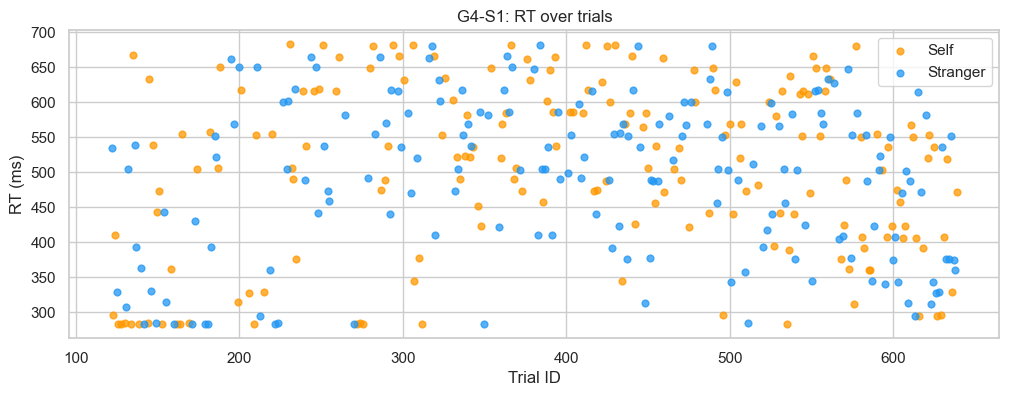

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
for identity, color in [("Self", "#ff9800"), ("Stranger", "#2196f3")]:
    d = responded[responded["Identity"].eq(identity)]
    ax.scatter(d["trialID"], d["RT_ms"], s=24, alpha=0.75, label=identity, c=color)
ax.set_title(f"G{GROUP_ID}-S{SUBJECT_ID}: RT over trials")
ax.set_xlabel("Trial ID")
ax.set_ylabel("RT (ms)")
ax.legend()
plt.show()

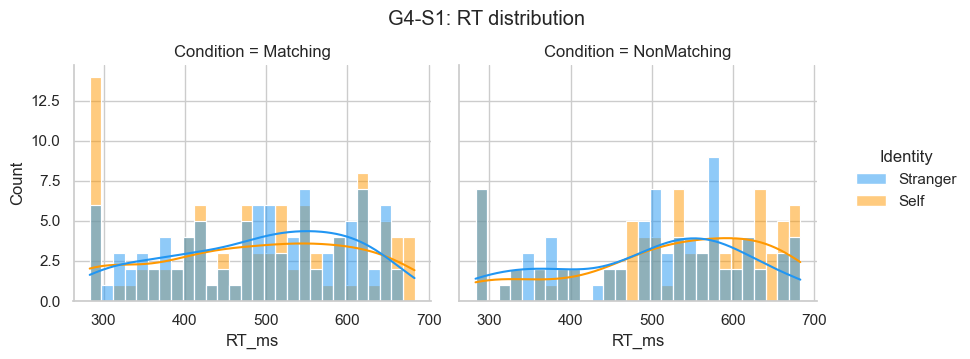

In [12]:
if sns is not None:
    g = sns.displot(
        data=responded,
        x="RT_ms",
        hue="Identity",
        col="Condition",
        kind="hist",
        kde=True,
        bins=28,
        height=3.4,
        aspect=1.25,
        palette={"Self": "#ff9800", "Stranger": "#2196f3"},
    )
    g.fig.suptitle(f"G{GROUP_ID}-S{SUBJECT_ID}: RT distribution", y=1.05)
    plt.show()
else:
    responded.hist(column="RT_ms", by=["Condition", "Identity"], bins=28, figsize=(10, 6))
    plt.show()

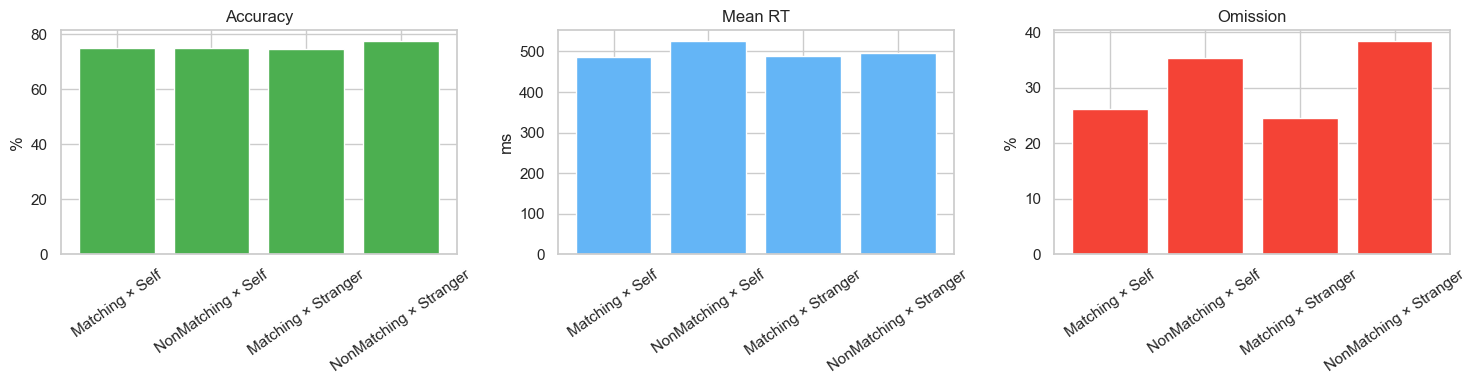

Response                f    j  nan  All
Identity Condition                      
Self     Matching      72   24   34  130
         NonMatching   21   63   46  130
Stranger Matching      73   25   32  130
         NonMatching   18   62   50  130
All                   184  174  162  520

,Identity,Condition,P(response=match key) %
0,Self,Matching,75.0
1,Self,NonMatching,25.0
2,Stranger,Matching,74.5
3,Stranger,NonMatching,22.5


In [13]:
plot_df = subj_summary.copy()
plot_df["cell"] = plot_df["Condition"] + " × " + plot_df["Identity"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(plot_df["cell"], plot_df["accuracy"] * 100, color="#4caf50")
axes[0].set_title("Accuracy")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(plot_df["cell"], plot_df["rt_mean_ms"], color="#64b5f6")
axes[1].set_title("Mean RT")
axes[1].set_ylabel("ms")
axes[1].tick_params(axis="x", rotation=35)
axes[2].bar(plot_df["cell"], plot_df["omission_rate"] * 100, color="#f44336")
axes[2].set_title("Omission")
axes[2].set_ylabel("%")
axes[2].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

resp_table = pd.crosstab([formal["Identity"], formal["Condition"]], formal["Response"], margins=True)
match_resp = responded.groupby(["Identity", "Condition"], observed=True)["ResponseIsMatch"].mean().mul(100).rename("P(response=match key) %").reset_index()
display(resp_table)
display(match_resp.style.format({"P(response=match key) %": "{:.1f}"}))

## CRF 与 SPE 曲线：复现网页的核心动态指标

这里的 CRF 不是简单的 `Condition == Matching` 比例，而是：

> 在 RT 分位数 bin 内，被试按“匹配键”的比例 `P(ResponseIsMatch)`。

分别对 Self 和 Stranger 计算 CRF 后，定义：

> `SPE_CRF = P_match_key(Self) - P_match_key(Stranger)`

In [14]:
def compute_crf(trials: pd.DataFrame, n_quantiles: int = 5) -> pd.DataFrame:
    d = trials[(trials["stage"].eq("formal")) & (trials["responded"]) & trials["RT"].notna()].copy()
    d = d.sort_values("RT").reset_index(drop=True)
    if len(d) < n_quantiles * 2:
        return pd.DataFrame()
    bins = []
    q_size = len(d) // n_quantiles
    start = 0
    for i in range(n_quantiles):
        end = len(d) if i == n_quantiles - 1 else start + q_size
        b = d.iloc[start:end]
        p = b["ResponseIsMatch"].astype(float).mean()
        sd = b["ResponseIsMatch"].astype(float).std(ddof=1)
        bins.append({
            "bin": i + 1,
            "n": len(b),
            "rt_mean": b["RT"].mean(),
            "rt_mean_ms": b["RT_ms"].mean(),
            "rt_min_ms": b["RT_ms"].min(),
            "rt_max_ms": b["RT_ms"].max(),
            "upper_prop": p,
            "sem": sd / math.sqrt(len(b)) if len(b) > 1 else 0,
        })
        start = end
    return pd.DataFrame(bins)

def compute_spe_crf(trials: pd.DataFrame, n_quantiles: int = 5):
    crf_self = compute_crf(trials[trials["Identity"].eq("Self")], n_quantiles)
    crf_stranger = compute_crf(trials[trials["Identity"].eq("Stranger")], n_quantiles)
    m = min(len(crf_self), len(crf_stranger))
    if m == 0:
        return crf_self, crf_stranger, pd.DataFrame()
    spe = pd.DataFrame({
        "bin": np.arange(1, m + 1),
        "rt_mean_ms": (crf_self["rt_mean_ms"].iloc[:m].to_numpy() + crf_stranger["rt_mean_ms"].iloc[:m].to_numpy()) / 2,
        "spe_upper_prop": crf_self["upper_prop"].iloc[:m].to_numpy() - crf_stranger["upper_prop"].iloc[:m].to_numpy(),
        "spe_sem": np.sqrt(crf_self["sem"].iloc[:m].to_numpy() ** 2 + crf_stranger["sem"].iloc[:m].to_numpy() ** 2),
    })
    return crf_self, crf_stranger, spe

crf_self, crf_stranger, spe_curve = compute_spe_crf(formal, n_quantiles=5)
display(crf_self)
display(crf_stranger)
display(spe_curve)

,bin,n,rt_mean,rt_mean_ms,rt_min_ms,rt_max_ms,upper_prop,sem
0,1,36,0.313520,313.519956,283.1917,388.9378,0.555556,0.083992
1,2,36,0.441655,441.655386,391.8831,487.1473,0.611111,0.082402
2,3,36,0.522640,522.640336,488.3014,552.8220,0.472222,0.084385
3,4,36,0.589393,589.392500,553.8323,617.9850,0.500000,0.084515
4,5,36,0.657047,657.046939,618.1938,682.6904,0.444444,0.083992


,bin,n,rt_mean,rt_mean_ms,rt_min_ms,rt_max_ms,upper_prop,sem
0,1,35,0.320458,320.458320,283.0340,375.6084,0.314286,0.079615
1,2,35,0.424899,424.898683,375.8956,487.5060,0.628571,0.082866
2,3,35,0.507890,507.889597,487.6317,537.4478,0.542857,0.085434
3,4,35,0.565100,565.099509,538.1488,585.9637,0.514286,0.085714
4,5,38,0.632385,632.384632,586.4885,681.4508,0.552632,0.081743


,bin,rt_mean_ms,spe_upper_prop,spe_sem
0,1,316.989138,0.241270,0.115729
1,2,433.277034,-0.017460,0.116863
2,3,515.264967,-0.070635,0.120082
3,4,577.246004,-0.014286,0.120374
4,5,644.715785,-0.108187,0.117203


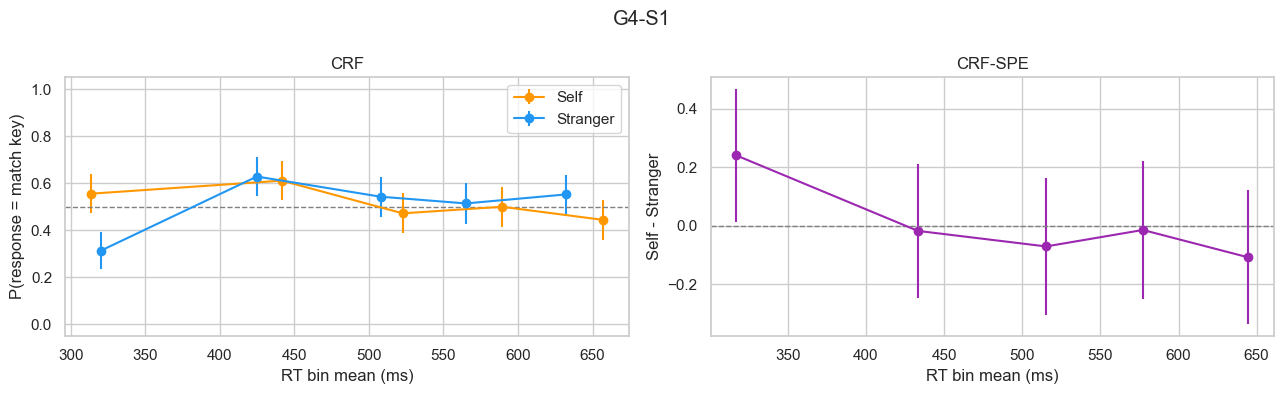

In [15]:
def plot_crf_and_spe(crf_self, crf_stranger, spe_curve, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ax = axes[0]
    if len(crf_self):
        ax.errorbar(crf_self["rt_mean_ms"], crf_self["upper_prop"], yerr=crf_self["sem"], marker="o", color="#ff9800", label="Self")
    if len(crf_stranger):
        ax.errorbar(crf_stranger["rt_mean_ms"], crf_stranger["upper_prop"], yerr=crf_stranger["sem"], marker="o", color="#2196f3", label="Stranger")
    ax.axhline(0.5, ls="--", color="gray", lw=1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("RT bin mean (ms)")
    ax.set_ylabel("P(response = match key)")
    ax.set_title("CRF")
    ax.legend()

    ax = axes[1]
    if len(spe_curve):
        ax.errorbar(spe_curve["rt_mean_ms"], spe_curve["spe_upper_prop"], yerr=1.96 * spe_curve["spe_sem"], marker="o", color="#9c27b0")
    ax.axhline(0, ls="--", color="gray", lw=1)
    ax.set_xlabel("RT bin mean (ms)")
    ax.set_ylabel("Self - Stranger")
    ax.set_title("CRF-SPE")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_crf_and_spe(crf_self, crf_stranger, spe_curve, title=f"G{GROUP_ID}-S{SUBJECT_ID}")

## 全被试 summary：每个被试的 SPE 与质量指标

核心列：

- `spe_acc`: `ACC_self - ACC_stranger`，越大表示 Self 更准确。
- `spe_rt_ms`: `RT_stranger_correct - RT_self_correct`，越大表示 Self 更快。
- `spe_match_key`: `P(response match key | Self) - P(response match key | Stranger`，对应 CRF 的整体版本。
- `omission_rate`: 时限/任务可完成性的重要指标，建模时不要忽略。

In [16]:
def safe_mean(s):
    return s.mean() if len(s) else np.nan

def summarize_subject(g: pd.DataFrame) -> pd.Series:
    f = g[g["stage"].eq("formal")]
    r = f[f["responded"]]
    corr = r[r["Correct"].eq(1)]
    self_r = r[r["Identity"].eq("Self")]
    st_r = r[r["Identity"].eq("Stranger")]
    self_corr = corr[corr["Identity"].eq("Self")]
    st_corr = corr[corr["Identity"].eq("Stranger")]
    acc_self = safe_mean(self_r["Correct"])
    acc_st = safe_mean(st_r["Correct"])
    rt_self = safe_mean(self_corr["RT_ms"])
    rt_st = safe_mean(st_corr["RT_ms"])
    match_self = safe_mean(self_r["ResponseIsMatch"].astype(float))
    match_st = safe_mean(st_r["ResponseIsMatch"].astype(float))
    return pd.Series({
        "n_formal": len(f),
        "n_response": len(r),
        "omission_rate": 1 - len(r) / max(len(f), 1),
        "accuracy": safe_mean(r["Correct"]),
        "mean_rt_ms": safe_mean(r["RT_ms"]),
        "median_rt_ms": r["RT_ms"].median(),
        "acc_self": acc_self,
        "acc_stranger": acc_st,
        "spe_acc": acc_self - acc_st,
        "correct_rt_self_ms": rt_self,
        "correct_rt_stranger_ms": rt_st,
        "spe_rt_ms": rt_st - rt_self,
        "p_match_key_self": match_self,
        "p_match_key_stranger": match_st,
        "spe_match_key": match_self - match_st,
        "P": g["P"].iloc[0],
        "T_ms": g["T_ms"].iloc[0],
        "W_ms": g["W_ms"].iloc[0],
        "M_ms": g["M_ms"].iloc[0],
        "quality": g["quality"].iloc[0],
        "source_file": g["source_file"].iloc[0],
    })

subject_level = (
    all_df.groupby(["groupID", "subjectID"], observed=True)
    .apply(summarize_subject)
    .reset_index()
    .sort_values(["groupID", "subjectID"])
)
display(subject_level.head())
display(subject_level.select_dtypes(include=[np.number]).describe().T)

subject_level_path = OUT_DIR / "subject_level_behavior_features.csv"
subject_level.to_csv(subject_level_path, index=False, encoding="utf-8-sig")
print("saved:", subject_level_path)

C:\Users\蔡振辛\AppData\Local\Temp\ipykernel_147144\4244994353.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_subject)


,groupID,subjectID,n_formal,n_response,omission_rate,accuracy,mean_rt_ms,median_rt_ms,acc_self,acc_stranger,spe_acc,correct_rt_self_ms,correct_rt_stranger_ms,spe_rt_ms,p_match_key_self,p_match_key_stranger,spe_match_key,P,T_ms,W_ms,M_ms,quality,source_file
0,1,1,520,100,0.807692,0.490000,253.650110,235.64260,0.509804,0.469388,0.040416,265.002196,254.493809,-10.508387,0.745098,0.551020,0.194078,0,30.0,300.0,330.0,exclude,EXP_data_group1_1.csv
1,1,2,520,184,0.646154,0.451087,269.159260,268.02600,0.465347,0.433735,0.031612,270.655013,262.964489,-7.690524,0.485149,0.566265,-0.081117,0,30.0,300.0,330.0,exclude,EXP_data_group1_2.csv
2,1,3,520,114,0.780769,0.438596,271.211771,271.34260,0.413793,0.464286,-0.050493,268.674533,282.419050,13.744517,0.775862,0.732143,0.043719,0,30.0,300.0,330.0,exclude,EXP_data_group1_3.csv
3,1,4,520,224,0.569231,0.486607,256.413351,235.81095,0.517857,0.455357,0.062500,254.946879,247.110137,-7.836742,0.767857,0.705357,0.062500,0,30.0,300.0,330.0,exclude,EXP_data_group1_4.csv
4,1,5,520,126,0.757692,0.571429,256.961671,235.42700,0.528571,0.625000,-0.096429,265.294311,255.637980,-9.656331,0.871429,0.928571,-0.057143,0,30.0,300.0,330.0,exclude,EXP_data_group1_5.csv


,count,mean,std,min,25%,50%,75%,max
groupID,88.0,4.500000,2.324285,1.000000,2.000000,4.500000,7.000000,8.000000
subjectID,88.0,6.625000,3.812600,1.000000,3.000000,6.000000,10.000000,16.000000
n_formal,88.0,520.000000,0.000000,520.000000,520.000000,520.000000,520.000000,520.000000
n_response,88.0,356.068182,138.719828,59.000000,258.500000,402.000000,481.000000,514.000000
omission_rate,88.0,0.315253,0.266769,0.011538,0.075000,0.226923,0.502885,0.886538
accuracy,88.0,0.687502,0.174006,0.430894,0.512077,0.722436,0.859564,0.988304
mean_rt_ms,88.0,553.570482,199.981304,241.016157,400.881775,547.692822,647.921469,1066.129226
median_rt_ms,88.0,539.045209,192.881462,233.856100,361.342200,568.754700,637.374625,976.801000
acc_self,88.0,0.720586,0.183479,0.413793,0.515073,0.763112,0.878466,0.984436
acc_stranger,88.0,0.648182,0.180920,0.354430,0.485493,0.602625,0.827723,0.992188


saved: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\Visualization\V2\outputs\subject_level_behavior_features.csv


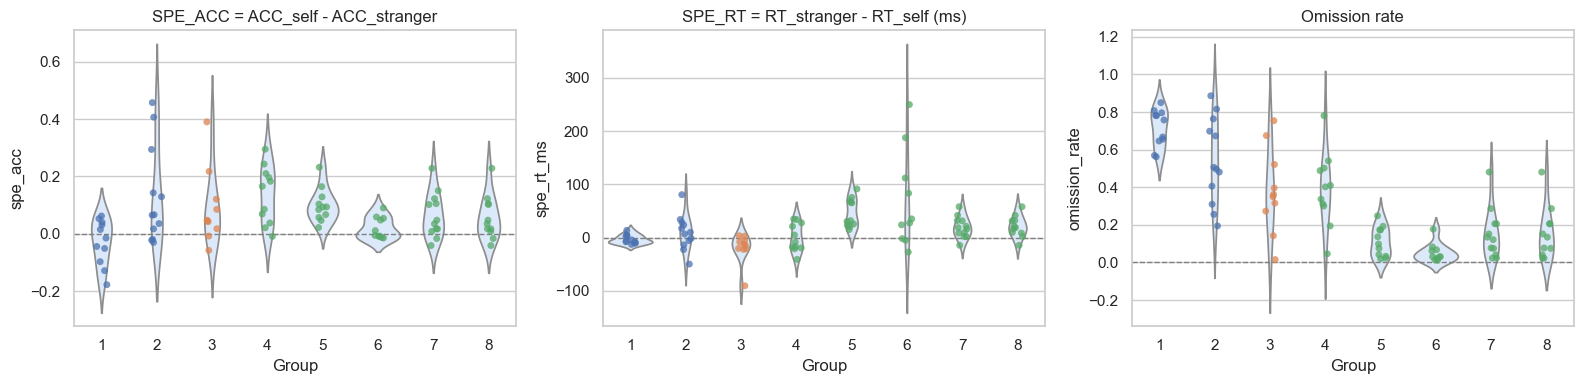

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = [("spe_acc", "SPE_ACC = ACC_self - ACC_stranger"), ("spe_rt_ms", "SPE_RT = RT_stranger - RT_self (ms)"), ("omission_rate", "Omission rate")]
for ax, (col, title) in zip(axes, metrics):
    if sns is not None:
        sns.violinplot(data=subject_level, x="groupID", y=col, inner=None, color="#d7e8ff", ax=ax)
        sns.stripplot(data=subject_level, x="groupID", y=col, hue="quality", dodge=False, size=5, alpha=0.75, ax=ax)
        if ax.legend_:
            ax.legend_.remove()
    else:
        subject_level.boxplot(column=col, by="groupID", ax=ax)
    ax.axhline(0, ls="--", color="gray", lw=1)
    ax.set_title(title)
    ax.set_xlabel("Group")
plt.tight_layout()
plt.show()

In [18]:
group_level = subject_level.groupby("groupID", observed=True).agg(
    n_subjects=("subjectID", "nunique"),
    P=("P", "first"),
    T_ms=("T_ms", "first"),
    W_ms=("W_ms", "first"),
    M_ms=("M_ms", "first"),
    quality=("quality", "first"),
    accuracy_mean=("accuracy", "mean"),
    accuracy_sd=("accuracy", "std"),
    omission_mean=("omission_rate", "mean"),
    spe_acc_mean=("spe_acc", "mean"),
    spe_acc_sd=("spe_acc", "std"),
    spe_rt_ms_mean=("spe_rt_ms", "mean"),
    spe_rt_ms_sd=("spe_rt_ms", "std"),
    spe_match_key_mean=("spe_match_key", "mean"),
).reset_index()
group_level_path = OUT_DIR / "group_level_design_space_summary.csv"
group_level.to_csv(group_level_path, index=False, encoding="utf-8-sig")
display(group_level)
print("saved:", group_level_path)

,groupID,n_subjects,P,T_ms,W_ms,M_ms,quality,accuracy_mean,accuracy_sd,omission_mean,spe_acc_mean,spe_acc_sd,spe_rt_ms_mean,spe_rt_ms_sd,spe_match_key_mean
0,1,11,0,30.0,300.0,330.0,exclude,0.503214,0.038595,0.715909,-0.027795,0.079069,-2.985375,8.279221,0.009326
1,2,12,0,30.0,600.0,630.0,exclude,0.551520,0.127742,0.540385,0.128900,0.168073,9.099071,32.600594,0.128027
2,3,10,120,30.0,600.0,630.0,caution,0.512475,0.046269,0.380385,0.090423,0.128879,-18.743787,26.779429,0.089276
3,4,11,120,80.0,600.0,680.0,good,0.701323,0.118500,0.391958,0.136415,0.099739,-0.074076,26.020983,0.134930
4,5,11,8,100.0,1100.0,1200.0,good,0.770759,0.096873,0.110315,0.099753,0.058747,46.811511,26.879788,0.087538
5,6,10,120,500.0,1500.0,2000.0,good,0.939023,0.031423,0.052500,0.021649,0.037908,68.534230,90.308555,0.033259
6,7,12,120,30.0,800.0,830.0,good,0.756189,0.148159,0.152083,0.065110,0.077953,19.005243,19.716405,0.083020
7,8,11,120,80.0,800.0,880.0,good,0.778583,0.132386,0.154895,0.057333,0.076721,20.571077,19.880796,0.080869


saved: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\Visualization\V2\outputs\group_level_design_space_summary.csv


## 设计空间：P/T/W 与 SPE 的关系

下面几张图相当于网页“设计空间分析”的 notebook 版本：

- `T × W` bubble：点大小可理解为 P 或样本量，颜色为组级 SPE。
- 3D scatter：P/T/W 空间中的组级 SPE。
- 被试级散点：展示组内离散度，而不是只看均值。

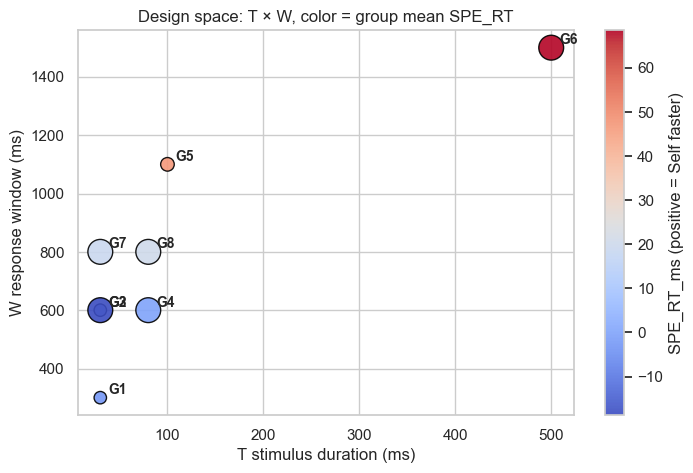

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    group_level["T_ms"],
    group_level["W_ms"],
    s=80 + group_level["P"] * 2,
    c=group_level["spe_rt_ms_mean"],
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.9,
)
for _, row in group_level.iterrows():
    ax.text(row["T_ms"] + 8, row["W_ms"] + 12, f"G{int(row['groupID'])}", fontsize=10, weight="bold")
ax.set_xlabel("T stimulus duration (ms)")
ax.set_ylabel("W response window (ms)")
ax.set_title("Design space: T × W, color = group mean SPE_RT")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("SPE_RT_ms (positive = Self faster)")
plt.show()

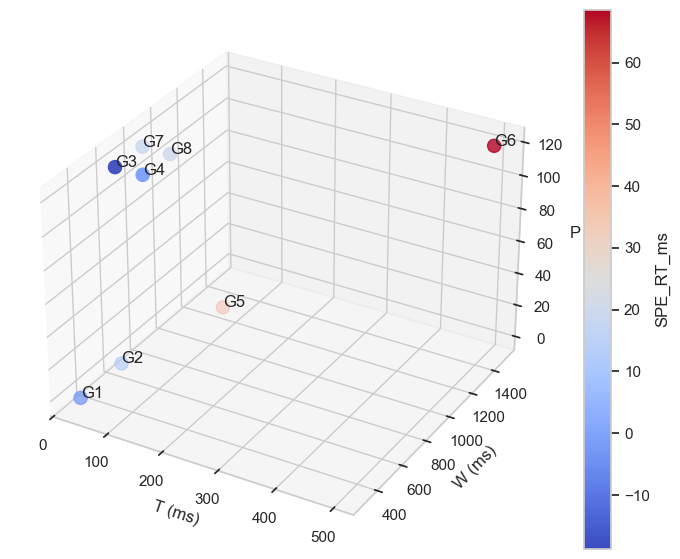

In [20]:
if PLOTLY_AVAILABLE:
    fig = px.scatter_3d(
        group_level,
        x="T_ms",
        y="W_ms",
        z="P",
        color="spe_rt_ms_mean",
        size=np.clip(group_level["n_subjects"], 4, None),
        hover_name=group_level["groupID"].map(lambda x: f"G{x}"),
        hover_data=["quality", "spe_acc_mean", "spe_rt_ms_mean", "omission_mean"],
        color_continuous_scale="RdBu_r",
        title="3D design space: T × W × P, color = SPE_RT",
    )
    fig.update_layout(scene=dict(xaxis_title="T (ms)", yaxis_title="W (ms)", zaxis_title="P"), height=650)
    fig.show()
else:
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    p = ax.scatter(group_level["T_ms"], group_level["W_ms"], group_level["P"], c=group_level["spe_rt_ms_mean"], cmap="coolwarm", s=90)
    for _, row in group_level.iterrows():
        ax.text(row["T_ms"], row["W_ms"], row["P"], f"G{int(row['groupID'])}")
    ax.set_xlabel("T (ms)")
    ax.set_ylabel("W (ms)")
    ax.set_zlabel("P")
    plt.colorbar(p, ax=ax, label="SPE_RT_ms")
    plt.show()

In [21]:
if PLOTLY_AVAILABLE:
    fig = px.scatter_3d(
        subject_level,
        x="T_ms",
        y="W_ms",
        z="P",
        color="spe_rt_ms",
        symbol="quality",
        hover_data=["groupID", "subjectID", "spe_acc", "spe_rt_ms", "omission_rate", "accuracy"],
        color_continuous_scale="RdBu_r",
        title="Subject-level SPE in design space",
    )
    fig.update_layout(scene=dict(xaxis_title="T (ms)", yaxis_title="W (ms)", zaxis_title="P"), height=650)
    fig.show()
else:
    display(subject_level[["groupID", "subjectID", "P", "T_ms", "W_ms", "spe_rt_ms", "spe_acc", "omission_rate"]].head())

,groupID,subjectID,P,T_ms,W_ms,spe_rt_ms,spe_acc,omission_rate
0,1,1,0,30.0,300.0,-10.508387,0.040416,0.807692
1,1,2,0,30.0,300.0,-7.690524,0.031612,0.646154
2,1,3,0,30.0,300.0,13.744517,-0.050493,0.780769
3,1,4,0,30.0,300.0,-7.836742,0.062500,0.569231
4,1,5,0,30.0,300.0,-9.656331,-0.096429,0.757692


## 条件差异总览：Identity / Condition / Response 的 RT 与 ACC

这部分回答第 ① 个问题：不同条件下 RT、ACC 的差异。

C:\Users\蔡振辛\AppData\Local\Temp\ipykernel_147144\2633763949.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,groupID,subjectID,Identity,Condition,n_trials,n_response,omission_rate,accuracy,mean_rt_ms,correct_rt_ms,p_match_key,P,T_ms,W_ms
0,1,1,Self,Matching,130.0,25.0,0.807692,0.760000,260.503700,263.868084,0.760000,0.0,30.0,300.0
1,1,1,Self,NonMatching,130.0,26.0,0.800000,0.269231,251.586650,268.080500,0.730769,0.0,30.0,300.0
2,1,1,Stranger,Matching,130.0,21.0,0.838462,0.523810,247.348695,252.242955,0.523810,0.0,30.0,300.0
3,1,1,Stranger,NonMatching,130.0,28.0,0.784615,0.428571,254.172964,256.557092,0.571429,0.0,30.0,300.0
4,1,2,Self,Matching,130.0,51.0,0.607692,0.450980,272.660908,275.990913,0.450980,0.0,30.0,300.0


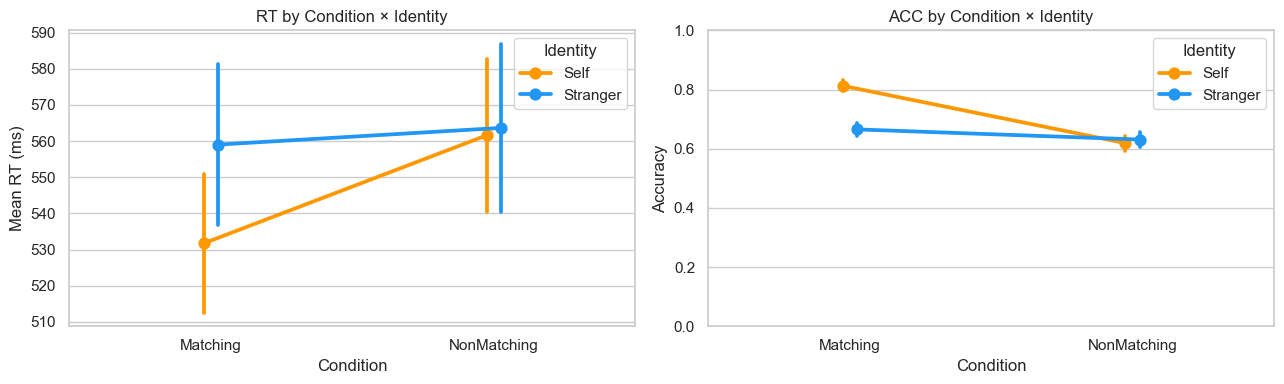

In [22]:
condition_level = (
    all_df[all_df["stage"].eq("formal")]
    .groupby(["groupID", "subjectID", "Identity", "Condition"], observed=True)
    .apply(lambda g: pd.Series({
        "n_trials": len(g),
        "n_response": g["responded"].sum(),
        "omission_rate": 1 - g["responded"].sum() / max(len(g), 1),
        "accuracy": g.loc[g["responded"], "Correct"].mean(),
        "mean_rt_ms": g.loc[g["responded"], "RT_ms"].mean(),
        "correct_rt_ms": g.loc[g["responded"] & g["Correct"].eq(1), "RT_ms"].mean(),
        "p_match_key": g.loc[g["responded"], "ResponseIsMatch"].astype(float).mean(),
        "P": g["P"].iloc[0],
        "T_ms": g["T_ms"].iloc[0],
        "W_ms": g["W_ms"].iloc[0],
    }))
    .reset_index()
)
display(condition_level.head())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if sns is not None:
    sns.pointplot(data=condition_level, x="Condition", y="mean_rt_ms", hue="Identity", dodge=True, errorbar="se", ax=axes[0], palette={"Self": "#ff9800", "Stranger": "#2196f3"})
    sns.pointplot(data=condition_level, x="Condition", y="accuracy", hue="Identity", dodge=True, errorbar="se", ax=axes[1], palette={"Self": "#ff9800", "Stranger": "#2196f3"})
else:
    condition_level.groupby(["Condition", "Identity"])["mean_rt_ms"].mean().unstack().plot(kind="bar", ax=axes[0])
    condition_level.groupby(["Condition", "Identity"])["accuracy"].mean().unstack().plot(kind="bar", ax=axes[1])
axes[0].set_title("RT by Condition × Identity")
axes[0].set_ylabel("Mean RT (ms)")
axes[1].set_title("ACC by Condition × Identity")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 设计空间对 SPE 的影响：建模前的探索

这部分回答第 ② 个问题：不同 `P | T | W` 组合下，每个被试的 SPE 分布。

请优先观察：

- 高遗漏组是否也出现极端 SPE？这可能不是真实 self advantage，而是时限造成的选择偏差。
- `P` 的练习效应是否主要影响 ACC、RT，还是影响 CRF 的匹配键概率。
- `T/W/M` 是否更像控制 RT/omission 的机制，而不是直接控制 self/stranger 差异。

In [23]:
corr_cols = ["P", "T_ms", "W_ms", "M_ms", "accuracy", "omission_rate", "spe_acc", "spe_rt_ms", "spe_match_key"]
corr = subject_level[corr_cols].corr()
display(corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}"))

spe_distribution = (
    subject_level.groupby(["groupID", "P", "T_ms", "W_ms"], observed=True)
    .agg(
        n=("subjectID", "count"),
        spe_rt_mean=("spe_rt_ms", "mean"),
        spe_rt_sd=("spe_rt_ms", "std"),
        spe_rt_q25=("spe_rt_ms", lambda s: s.quantile(0.25)),
        spe_rt_q50=("spe_rt_ms", "median"),
        spe_rt_q75=("spe_rt_ms", lambda s: s.quantile(0.75)),
        spe_acc_mean=("spe_acc", "mean"),
        omission_mean=("omission_rate", "mean"),
    )
    .reset_index()
)
display(spe_distribution)

,P,T_ms,W_ms,M_ms,accuracy,omission_rate,spe_acc,spe_rt_ms,spe_match_key
P,1.00,0.29,0.29,0.30,0.39,-0.45,0.03,0.01,0.04
T_ms,0.29,1.00,0.83,0.92,0.59,-0.43,-0.14,0.45,-0.14
W_ms,0.29,0.83,1.00,0.99,0.72,-0.71,-0.01,0.53,-0.05
M_ms,0.30,0.92,0.99,1.00,0.71,-0.65,-0.05,0.53,-0.08
accuracy,0.39,0.59,0.72,0.71,1.00,-0.63,0.07,0.50,-0.10
omission_rate,-0.45,-0.43,-0.71,-0.65,-0.63,1.00,0.15,-0.37,0.14
spe_acc,0.03,-0.14,-0.01,-0.05,0.07,0.15,1.00,0.05,0.36
spe_rt_ms,0.01,0.45,0.53,0.53,0.50,-0.37,0.05,1.00,0.02
spe_match_key,0.04,-0.14,-0.05,-0.08,-0.10,0.14,0.36,0.02,1.00


,groupID,P,T_ms,W_ms,n,spe_rt_mean,spe_rt_sd,spe_rt_q25,spe_rt_q50,spe_rt_q75,spe_acc_mean,omission_mean
0,1,0,30.0,300.0,11,-2.985375,8.279221,-8.746536,-6.323870,3.544888,-0.027795,0.715909
1,2,0,30.0,600.0,12,9.099071,32.600594,-7.524585,8.419932,24.984295,0.128900,0.540385
2,3,120,30.0,600.0,10,-18.743787,26.779429,-20.534407,-13.366189,-6.132949,0.090423,0.380385
3,4,120,80.0,600.0,11,-0.074076,26.020983,-18.491971,-8.159099,24.480441,0.136415,0.391958
4,5,8,100.0,1100.0,11,46.811511,26.879788,24.499114,31.952725,67.775121,0.099753,0.110315
5,6,120,500.0,1500.0,10,68.534230,90.308555,4.647761,31.346144,104.695496,0.021649,0.052500
6,7,120,30.0,800.0,12,19.005243,19.716405,7.005211,17.627542,31.707403,0.065110,0.152083
7,8,120,80.0,800.0,11,20.571077,19.880796,9.181966,18.858141,31.834486,0.057333,0.154895


## Sigmoid 生成模型接口：从行为表到理论先验

如果你要构建或重新校准 Sigmoid 生成模型，可以从下面这些 target 开始：

- `accuracy` / `omission_rate`: 行为可完成性，帮助校准时限与边界机制。
- `spe_acc`: self vs stranger 的正确率优势。
- `spe_rt_ms`: self vs stranger 的速度优势，正值表示 Self 更快。
- `spe_match_key`: 接近 CRF/DDM 上边界命中概率差异。

一个实用做法：

1. 用 Sigmoid 函数表达 `T -> evidence quality`、`P -> practice`、`M=T+W -> time pressure/boundary`。
2. 用行为层 summary 先拟合可解释趋势，检查方向是否合理。
3. 再把 HDDM 参数层结果作为更高阶 target：`v_self/v_stranger/a/t/z`。

In [24]:
def sigmoid(x, x0, k):
    return 1 / (1 + np.exp(-k * (x - x0)))

model_table = subject_level.copy()
model_table["T_sigmoid_100ms"] = sigmoid(model_table["T_ms"], x0=100, k=0.01)
model_table["M_sigmoid_600ms"] = sigmoid(model_table["M_ms"], x0=600, k=0.01)
model_table["P_sigmoid_32"] = sigmoid(model_table["P"], x0=32, k=0.08)
model_table["log1p_P"] = np.log1p(model_table["P"])

feature_cols = ["P", "T_ms", "W_ms", "M_ms", "T_sigmoid_100ms", "M_sigmoid_600ms", "P_sigmoid_32", "log1p_P", "omission_rate"]
target_cols = ["accuracy", "spe_acc", "spe_rt_ms", "spe_match_key"]
display(model_table[["groupID", "subjectID"] + feature_cols + target_cols].head())

model_table_path = OUT_DIR / "model_ready_subject_table.csv"
model_table.to_csv(model_table_path, index=False, encoding="utf-8-sig")
print("saved:", model_table_path)

,groupID,subjectID,P,T_ms,W_ms,M_ms,T_sigmoid_100ms,M_sigmoid_600ms,P_sigmoid_32,log1p_P,omission_rate,accuracy,spe_acc,spe_rt_ms,spe_match_key
0,1,1,0,30.0,300.0,330.0,0.331812,0.062973,0.071758,0.0,0.807692,0.490000,0.040416,-10.508387,0.194078
1,1,2,0,30.0,300.0,330.0,0.331812,0.062973,0.071758,0.0,0.646154,0.451087,0.031612,-7.690524,-0.081117
2,1,3,0,30.0,300.0,330.0,0.331812,0.062973,0.071758,0.0,0.780769,0.438596,-0.050493,13.744517,0.043719
3,1,4,0,30.0,300.0,330.0,0.331812,0.062973,0.071758,0.0,0.569231,0.486607,0.062500,-7.836742,0.062500
4,1,5,0,30.0,300.0,330.0,0.331812,0.062973,0.071758,0.0,0.757692,0.571429,-0.096429,-9.656331,-0.057143


saved: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\Visualization\V2\outputs\model_ready_subject_table.csv


## GP 建模示例：行为层 SPE 的不确定性地图

下面是一个轻量 GP 示例，用组级均值建模 `SPE_RT_ms ~ P + T + W + M`。

注意：现在只有 8 个设计点，GP 的外推很不稳定。所以这里更适合用于：

- 画不确定性地图。
- 找“值得新增实验”的候选点。
- 与 Sigmoid 先验结合，做残差捕捉，而不是直接把 GP 当完整生成模型。

In [25]:
try:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("sklearn unavailable:", e)

print("sklearn available:", SKLEARN_AVAILABLE)

sklearn available: True


In [26]:
if SKLEARN_AVAILABLE:
    X = group_level[["P", "T_ms", "W_ms", "M_ms"]].to_numpy(float)
    y = group_level["spe_rt_ms_mean"].to_numpy(float)
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=30.0, noise_level_bounds=(1e-3, 1e4))
    gp = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42))
    gp.fit(X, y)
    print(gp[-1].kernel_)
    pred_mean, pred_std = gp.predict(X, return_std=True)
    fit_check = group_level[["groupID", "P", "T_ms", "W_ms", "spe_rt_ms_mean"]].copy()
    fit_check["gp_pred"] = pred_mean
    fit_check["gp_std"] = pred_std
    display(fit_check)
else:
    print("Skip GP cell because scikit-learn is not installed.")

1.31**2 * RBF(length_scale=[10.8, 1e+03, 1.7, 1e+03]) + WhiteKernel(noise_level=0.13)


c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,groupID,P,T_ms,W_ms,spe_rt_ms_mean,gp_pred,gp_std
0,1,0,30.0,300.0,-2.985375,-5.846337,12.405676
1,2,0,30.0,600.0,9.099071,3.733062,11.054224
2,3,120,30.0,600.0,-18.743787,-0.537655,10.620348
3,4,120,80.0,600.0,-0.074076,-0.537626,10.620351
4,5,8,100.0,1100.0,46.811511,46.725720,11.942527
5,6,120,500.0,1500.0,68.534230,65.486309,12.874340
6,7,120,30.0,800.0,19.005243,15.736454,10.693272
7,8,120,80.0,800.0,20.571077,15.736492,10.693271


In [27]:
if SKLEARN_AVAILABLE:
    candidate_grid = pd.DataFrame([
        {"P": P, "T_ms": T, "W_ms": W, "M_ms": T + W}
        for P in [0, 8, 15, 30, 60, 120]
        for T in [30, 80, 100, 200, 500]
        for W in [300, 600, 800, 1100, 1500]
    ])
    existing = set(tuple(x) for x in group_level[["P", "T_ms", "W_ms"]].round(6).to_numpy())
    candidate_grid["is_existing"] = [tuple(x) in existing for x in candidate_grid[["P", "T_ms", "W_ms"]].round(6).to_numpy()]
    cand = candidate_grid[~candidate_grid["is_existing"]].copy()
    mean, std = gp.predict(cand[["P", "T_ms", "W_ms", "M_ms"]].to_numpy(float), return_std=True)
    cand["pred_spe_rt_ms"] = mean
    cand["uncertainty"] = std
    cand["utility_uncertainty_plus_abs_pred"] = cand["uncertainty"] + 0.25 * cand["pred_spe_rt_ms"].abs()
    display(cand.sort_values("uncertainty", ascending=False).head(15))
    display(cand.sort_values("utility_uncertainty_plus_abs_pred", ascending=False).head(15))
    cand_path = OUT_DIR / "gp_candidate_design_points_behavior_spe.csv"
    cand.sort_values("utility_uncertainty_plus_abs_pred", ascending=False).to_csv(cand_path, index=False, encoding="utf-8-sig")
    print("saved:", cand_path)
else:
    print("Skip candidate generation because scikit-learn is not installed.")

,P,T_ms,W_ms,M_ms,is_existing,pred_spe_rt_ms,uncertainty,utility_uncertainty_plus_abs_pred
4,0,30,1500,1530,False,65.605458,13.857637,30.259002
9,0,80,1500,1580,False,65.605505,13.857566,30.258942
14,0,100,1500,1600,False,65.605523,13.857540,30.258920
19,0,200,1500,1700,False,65.605595,13.857434,30.258832
24,0,500,1500,2000,False,65.605671,13.857348,30.258766
29,8,30,1500,1530,False,65.653578,13.713683,30.127077
34,8,80,1500,1580,False,65.653625,13.713610,30.127016
39,8,100,1500,1600,False,65.653642,13.713583,30.126994
44,8,200,1500,1700,False,65.653715,13.713475,30.126904
49,8,500,1500,2000,False,65.653792,13.713386,30.126834


,P,T_ms,W_ms,M_ms,is_existing,pred_spe_rt_ms,uncertainty,utility_uncertainty_plus_abs_pred
4,0,30,1500,1530,False,65.605458,13.857637,30.259002
9,0,80,1500,1580,False,65.605505,13.857566,30.258942
14,0,100,1500,1600,False,65.605523,13.857540,30.258920
19,0,200,1500,1700,False,65.605595,13.857434,30.258832
24,0,500,1500,2000,False,65.605671,13.857348,30.258766
29,8,30,1500,1530,False,65.653578,13.713683,30.127077
34,8,80,1500,1580,False,65.653625,13.713610,30.127016
39,8,100,1500,1600,False,65.653642,13.713583,30.126994
44,8,200,1500,1700,False,65.653715,13.713475,30.126904
49,8,500,1500,2000,False,65.653792,13.713386,30.126834


saved: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\Visualization\V2\outputs\gp_candidate_design_points_behavior_spe.csv


In [28]:
if SKLEARN_AVAILABLE and PLOTLY_AVAILABLE:
    fig = px.scatter_3d(
        cand,
        x="T_ms",
        y="W_ms",
        z="P",
        color="uncertainty",
        size=np.clip(cand["pred_spe_rt_ms"].abs(), 5, 60),
        hover_data=["pred_spe_rt_ms", "utility_uncertainty_plus_abs_pred"],
        color_continuous_scale="Viridis",
        title="Candidate design grid: GP uncertainty for behavior-level SPE_RT",
    )
    fig.update_layout(scene=dict(xaxis_title="T (ms)", yaxis_title="W (ms)", zaxis_title="P"), height=650)
    fig.show()
elif SKLEARN_AVAILABLE:
    display(cand.sort_values("uncertainty", ascending=False).head(10))

,P,T_ms,W_ms,M_ms,is_existing,pred_spe_rt_ms,uncertainty,utility_uncertainty_plus_abs_pred
4,0,30,1500,1530,False,65.605458,13.857637,30.259002
9,0,80,1500,1580,False,65.605505,13.857566,30.258942
14,0,100,1500,1600,False,65.605523,13.857540,30.258920
19,0,200,1500,1700,False,65.605595,13.857434,30.258832
24,0,500,1500,2000,False,65.605671,13.857348,30.258766
29,8,30,1500,1530,False,65.653578,13.713683,30.127077
34,8,80,1500,1580,False,65.653625,13.713610,30.127016
39,8,100,1500,1600,False,65.653642,13.713583,30.126994
44,8,200,1500,1700,False,65.653715,13.713475,30.126904
49,8,500,1500,2000,False,65.653792,13.713386,30.126834


## 下一步建议

1. 先用这个 notebook 对每个被试做人工巡检：重点看高 omission、极端 RT、反常 SPE 的被试。
2. 对 G1/G2/G3 这类高遗漏组，建模时建议标记 `quality` 或加入 omission covariate，而不是直接与高质量组同权重拟合。
3. 行为层先建模，再接 HDDM 参数层：当前 8 个设计点对 GP 太少，但 88 个被试级点可以帮助判断组内变异和噪声结构。
4. 如果后续要新增实验，候选设计点不应只看 predicted SPE，还要看 GP uncertainty 与可行性：低 W 高 T 区域虽然信息量大，但可能再次造成高 omission。